In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from sklearn.datasets import load_digits
import pandas as pd
%matplotlib inline

 Load the digits Dataset

In [5]:
digits = load_digits()

In [6]:
X, y = digits.data, digits.target
print(X.shape, y.shape)

(1797, 64) (1797,)


We have 1797 images, each with 64 pixels of the (8x8) image

Let's look at the values of the first digit

In [7]:
X[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

## 1. Visualize a digit

Each image is a vector of 64 integers (8x8 pixels), where each integer represents a pixel's grayscale intensity.
Your task is to reshape these vectors into 8x8 arrays and visualize them using matplotlib. 

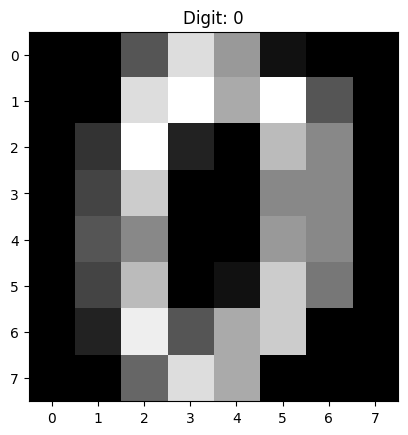

In [8]:
idx=0
# X[idx] gives you a 64 dimensional array of the pixel values
# You can reshape and array x using x.reshape(dim1, dim2) 
some_digit = X[idx].reshape(8, 8)

plt.imshow(some_digit, cmap='gray')
plt.title("Digit: " + str(y[idx]))
plt.show()

## 2. Define a 2x2 Grid Feature

A simple feature that you can define for this exercise is the average pixel intensity in different regions of the image.
Divide the 8x8 image into a 2x2 grid. Each cell in the grid will cover roughly 4x4 pixels of the image. Compute the average pixel intensity for each of these grid cells.
Implement a function to achieve this. Here’s a skeletal structure to get you started:

In [9]:
def compute_grid_features(image, grid=2):
    # Reshape the flat image into a 8x8 array if necessary
    image = image.reshape(8, 8)
    pixel_per_grid = int(np.ceil(8/grid))
    
    # Initialize an array to store the feature values
    features = np.zeros((grid, grid))
    
    # Loop over the grid and compute the average intensity
    for i in range(0, 8):
        for j in range(0, 8):
            features[i//pixel_per_grid, j//pixel_per_grid]+=image[i,j]

    features /= pixel_per_grid * pixel_per_grid
        
    return features.reshape(-1)

apply this to the image you plotted above

In [10]:
fs = compute_grid_features(X[idx], 2)
fs

array([5.125 , 4.6875, 4.25  , 4.3125])

## 3. Apply the Feature Extraction and Visualize it

Apply your compute_grid_features function to a few images (the 0,1,5 that appear in the first 50 images) and plot the top two features of the grid to see how it represents the original image.

In [403]:
N=50
features = np.asarray([ compute_grid_features(X[i], 2) for i in range(N)])
targets = y[0:N]  

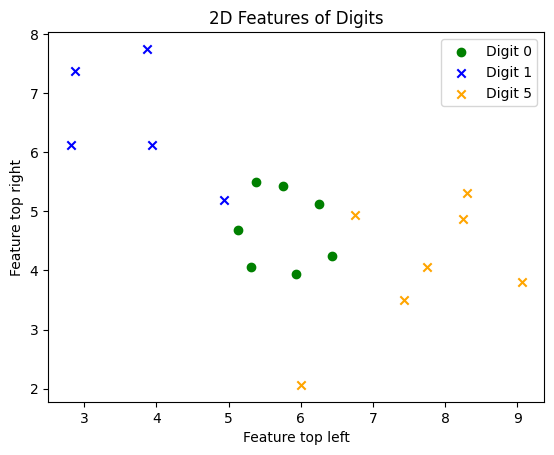

In [404]:
digit = 0
idx = np.where(targets == digit)
digit_features = features[idx]
plt.scatter(digit_features[:, 0], digit_features[:, 1], c='green', marker='o', label=f"Digit {digit}")

digit = 1
idx = np.where(targets == digit)
digit_features = features[idx]
plt.scatter(digit_features[:, 0], digit_features[:, 1], c='blue', marker='x', label=f"Digit {digit}")

digit = 5
idx = np.where(targets == digit)
digit_features = features[idx]
plt.scatter(digit_features[:, 0], digit_features[:, 1], c='orange', marker='x', label=f"Digit {digit}")


# Customize the plot
plt.xlabel('Feature top left')
plt.ylabel('Feature top right')
plt.title('2D Features of Digits')
plt.legend()
plt.show()

## 4. Clean up + Classify 0-digits using a add rectangle  
- modularize the code (write a function to plot points of one digit)
- add a suitable rectangle that would work as a classifier for the 0-digits (positives) vs 1 and 5 (negatives)

In [405]:
def plot_digit_features(features, targets, digit, color, marker, feature_1 = 0, feature_2 = 1):
    idx = np.where(targets == digit)
    digit_features = features[idx]
    plt.scatter(digit_features[:, feature_1], digit_features[:, feature_2], c=color, marker=marker, label=f"Digit {digit}")

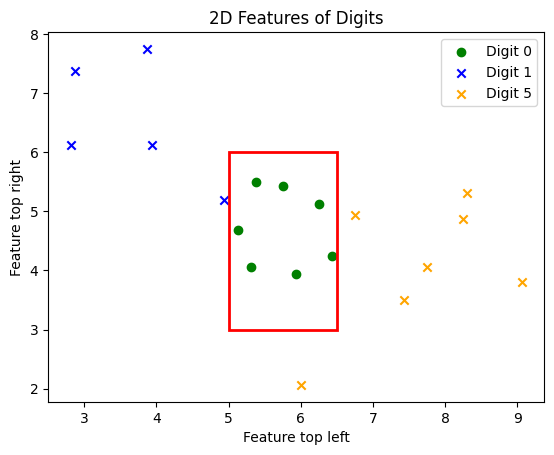

In [419]:
plot_digit_features(features, targets, 0, 'green','o')
plot_digit_features(features, targets, 1, 'blue','x')
plot_digit_features(features, targets, 5, 'orange','x')

# Define the rectangle lower and upper limits for each coordinate
l1=5; u1=6.5; l2=3; u2=6  # fill in numbers that you think would work when looking at the plot
# Rectangle in matplotlib wants: bottom-left corner at (x, y), with specified width and height
rect = Rectangle((l1, l2), u1-l1, u2-l2, linewidth=2, edgecolor='r', facecolor='none')
# Get current axis and add the rectangle to the plot
ax = plt.gca()
ax.add_patch(rect)

# Customize the plot
plt.xlabel('Feature top left')
plt.ylabel('Feature top right')
plt.title('2D Features of Digits')
plt.legend()
plt.show()

## 5. Test your classifier:
Now it is time to use our rectangle classifier and test it. Write a function that implements whether a datapoint is inside our outside the rectangle.

As test-set, use the next 450 images (index 50-500) (but only the ones of digit 0,1,5 as before)

Compute:
- false negatives and false negative rate
- false positives and false positive rate

In [427]:
N2=500
features_test = np.asarray([ compute_grid_features(X[i], 2) for i in range(N,N2)])
targets_test = y[N:N2]  

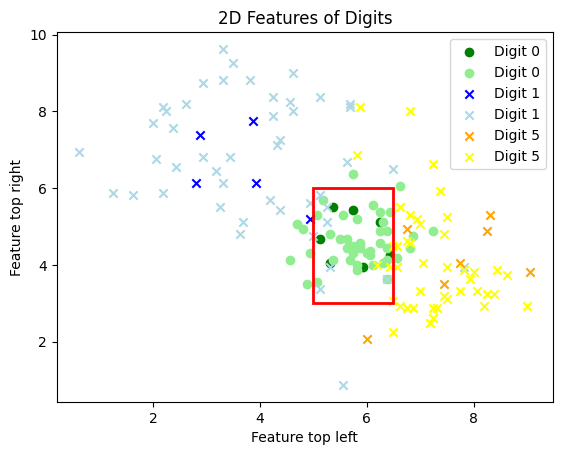

In [428]:
plot_digit_features(features, targets,           0, 'green','o')
plot_digit_features(features_test, targets_test, 0, 'lightgreen','o')
plot_digit_features(features, targets,           1, 'blue','x')
plot_digit_features(features_test, targets_test, 1, 'lightblue','x')
plot_digit_features(features, targets,           5, 'orange','x')
plot_digit_features(features_test, targets_test, 5, 'yellow','x')

rect = Rectangle((l1, l2), u1-l1, u2-l2, linewidth=2, edgecolor='r', facecolor='none')
# Get current axis and add the rectangle to the plot
ax = plt.gca()
ax.add_patch(rect)

# Customize the plot
plt.xlabel('Feature top left')
plt.ylabel('Feature top right')
plt.title('2D Features of Digits')
plt.legend()
plt.show()

In [429]:
def classifier(x, l1, u1, l2, u2):
    if x[0] >= l1 and x[0] <= u1 and x[1] >= l2 and x[1] <= u2:
        return True
    else:
        return False

make predictions for all 0s

In [430]:
idx = np.where(targets_test == 0)
digit_features = features_test[idx]
predict_true_pos = [ classifier(x[0:2], l1, u1, l2, u2) for x in digit_features ]
predict_true_pos[0:10]

[False, False, True, True, True, False, False, True, True, False]

False Negatives

In [431]:
sum(np.logical_not(predict_true_pos))

11

False Negative Rate

In [432]:
FN_rate =  sum(np.logical_not(predict_true_pos))/len(predict_true_pos)
FN_rate

0.25

make predictions for all 1 and 5s

In [433]:
idx = np.where(np.isin(targets_test,[1,5]))
digit_features = features_test[idx]
predict_true_neg = [ classifier(x[0:2], l1, u1, l2, u2) for x in digit_features ]
predict_true_neg[0:10]

[False, False, False, False, False, False, False, True, True, False]

False Positives

In [434]:
sum(predict_true_neg)

11

False Positive Rate

In [435]:
FP_rate =  sum(predict_true_neg)/len(predict_true_neg)
FP_rate

0.12222222222222222

## 6.* Check the other two features (Bonus)
Plot for the 2 other features of the grid (bottom left and bottom right). Discuss/answer the following questions by looking at the plots.
- when looking at the first 50, would you say it could work similarly as with the other features?
- when looking at the first 500?

In [394]:
N=50
features = np.asarray([ compute_grid_features(X[i], 2) for i in range(N)])
targets = y[0:N]  

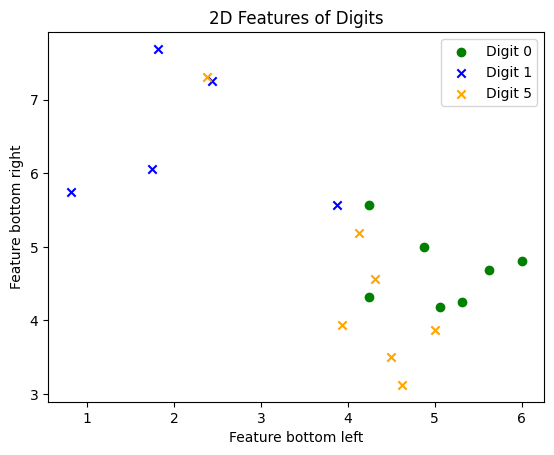

In [395]:
plot_digit_features(features, targets, 0, 'green','o',2,3)
plot_digit_features(features, targets, 1, 'blue','x',2,3)
plot_digit_features(features, targets, 5, 'orange','x',2,3)
# Customize the plot
plt.xlabel('Feature bottom left')
plt.ylabel('Feature bottom right')
plt.title('2D Features of Digits')
plt.legend()
plt.show()

Yes, could maybe work, but looks already worse.

In [396]:
N=500
features = np.asarray([ compute_grid_features(X[i], 2) for i in range(N)])
targets = y[0:N]  

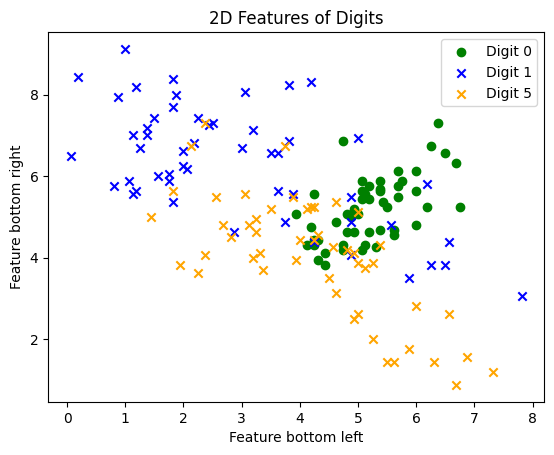

In [397]:
plot_digit_features(features, targets, 0, 'green','o',2,3)
plot_digit_features(features, targets, 1, 'blue','x',2,3)
plot_digit_features(features, targets, 5, 'orange','x',2,3)
# Customize the plot
plt.xlabel('Feature bottom left')
plt.ylabel('Feature bottom right')
plt.title('2D Features of Digits')
plt.legend()
plt.show()

Answer: looks like our features alone are not suitable